<a href="https://colab.research.google.com/github/properallan/ENE300/blob/main/tarefas/trabalho_1/trabalho_1_entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução


Deseja-se construir uma caixa com uma folha de papelão tamanho A4 ($210\times297$ mm), que possibilite armazenar o maior volume possível. A função $f$ modela o volume dessa caixa em função da espessura das margens, denotado por $x$. Dessa forma o problema pode ser forumalado como um problema de otimização, onde o objetivo é maximizar a funcão

$$
f(x) = 4x^3-1014x^2+62370x
$$

, sujeita à restrição 

$$
0 \leq x \leq 105
$$

A Figura a seguir apresenta graficamente a modelagem do problema. A restrição para o esse problema é obtida notando-se que nenhum dos comprimentos pode ser menor que zero e portanto

<center>
  <img src="https://github.com/properallan/ENE300/blob/main/tarefas/trabalho_1/A4.png?raw=1" width=40% style="margin-left:auto; margin-right:auto">
</center>


O problema em questão pode ser resolvido analiticamente, sabendo que o máximo para a função $f(x)$ ocorre em um ponto onde a derivada é nula

$$
\frac{df}{dx} = 12x^2-2028x+62370 = 0
$$

As duas raíves reais são 

$$
\begin{align}
x_1 =&  \frac{169}{2} - \frac{\sqrt{7771}}{2} \approx 40.42 \\
x_2 =&  \frac{169}{2} + \frac{\sqrt{7771}}{2} \approx 128.58
\end{align}
$$

Como a solução $x_2$ viola a restrição $x\leq105$ a possível solução para o problema é $x_1$, restando determinar se o ponto é realmente de máximo, analisando a segunda derifada da função

$$
\frac{d^2 f}{dx^2} \bigg\rvert_{x_1} = 24x-2028 \bigg\rvert_{x_1} = -1057.84
$$

, como $ \frac{d^2 f}{dx^2} \bigg\rvert_{x_1} < 0$, $x_1$ é ponto de máximo e portanto solução do problema propostos. Pela sua simplicidade o problema também poderia ser resolvido graficamente. 

A função `f(x)` é a implementação direta da função objetivo $f(x)$.

In [57]:
def f(x):
    return 4*x**3-1014*x**2+62370*x

Define-se um domínio discreto para a função $f$, como a função $f$ está definida em todo o domínio dos números reais, o domínio foi arbitrariamente escolhido no intervalo $-10 ≤ x ≤ 200$.



In [58]:
import numpy as np
x = np.linspace(-10, 200, 100)

Para a análise gráfica, plotamos o domínio viável de soluções representado pela região delimitada pelas restrições. Por meio de inspeção visual é possível estimar um valor candidato à ótimo em $x=40$. Apesar da simplicidade e eficacácia do método, ele pode tornar-se inviável para funções de multiplas variáveis e muitas restrições. Em geral deseja-se utilizar métodos numéricos, com algoritmos capazes de contornar esses problemas. Vamos estudar a *Busca Dicontômica*, *Método da Bissecção* e *Método de Newton*.

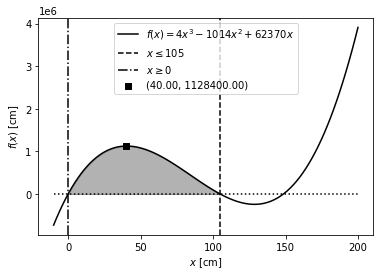

In [169]:
import matplotlib.pyplot as plt

def plot_problem(x, f, x_opt):
  # plot function
  plt.plot(x, f(x), c='k', label=rf'$f(x)=4x^3-1014x^2+62370x$')

  # plot restrictions
  plt.plot(x, np.zeros_like(x), c='k', ls=':')
  plt.axvline(105, c='k', ls='--', label=rf'$x \leq 105$')
  plt.axvline(0, c='k', ls='-.', label=rf'$x \geq 0$')

  # plot viable solutions
  plt.fill_between(x, 0, f(x), where=((x>=0) & (x<=105)), color='k', alpha=0.3)
  plt.xlabel(rf'$x$ [cm]')
  plt.ylabel(rf'$f(x)$ [cm]')

  # plot optimum solution
  plt.scatter(x_opt, f(x_opt), marker='s', c='k', label=rf'({x_opt:.2f}, {f(x_opt):.2f})')
  plt.legend()

x_opt=40
plot_problem(x, f, x_opt)


# Busca Dicotîmica

NO método de *Busca Dicontômica* divide, a cada nova iteração, o intervalo de busca é reduzido pela metade. Com a escolha adequada de $a, b$ e $\epsilon$ o método converge para o mínimo da função $f$, se $f$ for unimodal no intervalo $[a,b
]$, ou seja, se $f$ atinge o mínimo global $x^* \in \;]a,b[$ e para quaisquer $x_1,x_2 \in [a,b]$, verificar-se que

$$
\begin{align}
f(x_2) < f(x_1) \qquad &, se \; x_1 < x_2 < x^* \\
f(x_1) < f(x_2) \qquad &, se \; x^* < x_1 < x_2 
\end{align}
$$


Vamos descrever uma iteração do método. Escolhe-se dois pontos $x_1$ e $x_2$ suficientemente próximos do ponto médio de incerteza, para isso $\epsilon$ é escolhido muito pequeno. Um novo intervalo de busca é escolhido avaliando-se o valor da função nos pontos $x_1$ e $x_2$, verficando-se que $f(x_1) > f(x_2)$, define-se o novo intervalo $a=x_1$ e $b=b$, caso contrário, escolhe-se um novo intervalo $a=a$ e $b=x_2$. O algoritmo seque até atingir o critério de parada.

$$
\begin{align}
x_1 = \frac{a+b}{2}-\epsilon\\
x_2 = \frac{a+b}{2}+\epsilon
\end{align}
$$

<center>
  <img src="https://github.com/properallan/ENE300/blob/main/tarefas/trabalho_1/busca_dicotomica.png?raw=1" width=50% style="margin-left:auto; margin-right:auto">
</center>




A função `dichotomous_search` implementa o algoritmo proposto, com um critério de parada 

$$
|a-b| < 10 \epsilon
$$

, ou uma quantidade de iterações máxima fixada. Note $\epsilon$ não pode ser tão pequeno a pondo de erros de arredodamento tornarem o valor da função $f$ igual para $x_1$ e $x_2$.

In [160]:
def dichotomous_search(f, a, b, epsilon, objective='minimize', itmax=0):
    if objective == 'maximize':
      f_ = f
      f = lambda x: -f_(x)

    print(f"{'it':<6}{'a':>10}{'b':>10}{'error':>10}{'x1':>10}{'x2':>10}{'f_x1':>16}{'f_x2':>16}")
    it = 0
    error = epsilon*100.0
    while (error >= epsilon*10.0 and itmax == 0) or (itmax > 0 and it < itmax):
        x1 = (a + b)/2.0 - epsilon
        x2 = (a + b)/2.0 + epsilon
        f_x1 = f(x1)
        f_x2 = f(x2)
        if f_x1 > f_x2:
            a = x1
        else:
            b = x2

        it += 1
        error = abs(a-b)

        print(f"{it:<6d}{a:>10.4f}{b:>10.4f}{error:>10.4f}{x1:>10.4f}{x2:>10.4f}{f_x1:>16.4f}{f_x2:>16.4f}")
        x_opt = (a + b) / 2.0 
    print(f"x: {x_opt}")
        
    return x_opt

In [166]:
x_opt_ds = dichotomous_search(f, a=0.0, b=105.0 , epsilon=0.001, objective='maximize')

it             a         b     error        x1        x2            f_x1            f_x2
1         0.0000   52.5010   52.5010   52.4990   52.5010   -1058411.0246   -1058388.9746
2        26.2495   52.5010   26.2515   26.2495   26.2515   -1010845.9855   -1010880.7916
3        39.3742   52.5010   13.1268   39.3742   39.3762   -1127908.3377   -1127910.5816
4        39.3742   45.9386    6.5644   45.9366   45.9386   -1113088.3537   -1113077.4170
5        39.3742   42.6574    3.2832   42.6554   42.6574   -1125904.4245   -1125899.8197
6        39.3742   41.0168    1.6426   41.0148   41.0168   -1128310.8897   -1128309.6446
7        40.1945   41.0168    0.8223   40.1945   40.1965   -1128467.3645   -1128467.8477
8        40.1945   40.6067    0.4121   40.6047   40.6067   -1128477.7368   -1128477.3518
9        40.3996   40.6067    0.2071   40.3996   40.4016   -1128494.8066   -1128494.8547
10       40.3996   40.5042    0.1045   40.5022   40.5042   -1128491.8227   -1128491.6541
11       40.3996   40

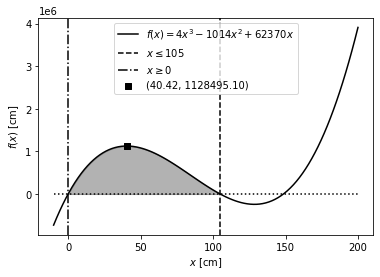

In [170]:
plot_problem(x, f, x_opt_ds)

# Método da Bissecção

Assim como no método da busca dicotômica, o método da bissecção elimina metada do intervalo de busca a cada nova iteração. Como novidade, temos que esse método utiliza a informação de derivada da função para atualizar os limites do intervalo.

<center>
  <img src="https://github.com/properallan/ENE300/blob/main/tarefas/trabalho_1/bisseccao.png?raw=1" width=50% style="margin-left:auto; margin-right:auto">
</center>

A cada iteração um novo intervalo é escolhido de acordo com o sinal da derivada qualculada no ponto médio $x_1=\frac{(a+b)}{2}$

$$
\begin{align}
a = x_1 \qquad &, se \; f'(x_1) < 0 \\
b = x_1\qquad &, se \; f'(x_1) > 0
\end{align}
$$

, como critério de parada foi escolhido um valor de $\epsilon$ para o valor absoluto da difereça entre as $i-ésimas$ iterações, ou um número máximo de iterações pré-determinado.

$$
|x_{i}-x_{i-1}| < \epsilon
$$

In [184]:
from autograd import grad

def newton_method(f, x0, epsilon, itmax=0):
    df = grad(f)
    d2f = grad(df)
    x = x0
    it = 0
    error = 2*epsilon

    print(f"{'it:<6'}{x_new}{f_x}")
    while (error >= epsilon and itmax==0) or (itmax > 0 and it < itmax):
        f_x = f(x)
        df_x = df(float(x))
        d2f_x = d2f(float(x))
        x_new = x - df_x / d2f_x
        print(f"Iteration {it}: x = {x_new}, f(x) = {f_x}")
    
        error=np.abs(x_new - x)
        x = x_new
        it += 1
    return x_new


In [186]:
f_ = lambda x: -f(x)
newton_method(f, 60.0, 0.0001)

Iteration 0: x = 32.602040816326536, f(x) = 955800.0
Iteration 1: x = 39.83400310576452, f(x) = 1094225.6498142784
Iteration 2: x = 40.41947395823086, f(x) = 1128310.5687480466
Iteration 3: x = 40.42336202570495, f(x) = 1128495.0967346004
Iteration 4: x = 40.42336219719113, f(x) = 1128495.1047312552


40.42336219719113